<a href="https://colab.research.google.com/github/sbsudip8/Quicktoto/blob/main/Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing the dependencies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Connect Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


loading the dataset to pandas dataframe

In [ ]:
credit_card_data=pd.read_csv('/content/drive/MyDrive/CreditCardFraud/creditcard.csv')

testing with printing the first five rows

In [ ]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


print the last five rows

In [ ]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


information of the dataset

In [ ]:
print(credit_card_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

number of missing values

In [ ]:
print(credit_card_data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


displaying...

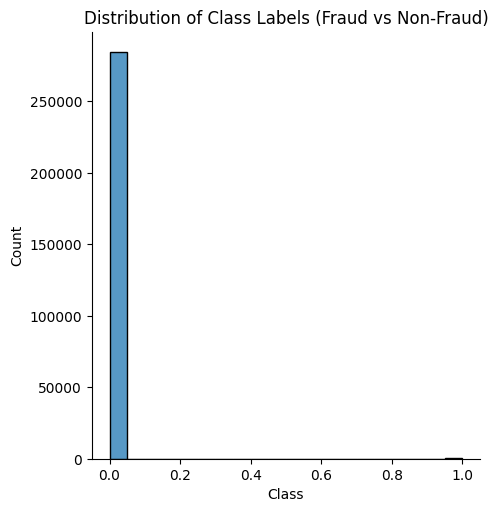

In [ ]:
sns.displot(credit_card_data['Class'])
plt.title('Distribution of Class Labels (Fraud vs Non-Fraud)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Distribution of legit and fradulant Transactions (0 means legit, 1 means fraudulant)

In [ ]:
print(credit_card_data['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


This dataset is highly unbalanced

Separating the data for analysis

In [ ]:
legit=credit_card_data[credit_card_data.Class==0]
fraud=credit_card_data[credit_card_data.Class==1]

In [ ]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


Statistical Measures about the data

In [ ]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


Compare the values for both transaction

In [ ]:
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Undersampling

Build a sample dataset comtaining similar distribution of normal and fraudulant transactions

In [ ]:
legit_sample=legit.sample(n=492)

Concatenating two dataframes to create an even dataset

In [ ]:
new_dataset=pd.concat([legit_sample,fraud],axis=0) #axis=0 to get rowwise concatenation

In [ ]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
17708,28859.0,1.331510,-0.778752,1.486884,-0.541383,-1.963501,-0.721183,-1.343324,0.038817,-0.141595,...,0.451776,1.252000,-0.035464,0.758122,0.259750,-0.061798,0.056184,0.035587,9.99,0
68437,52991.0,0.420921,1.897841,-1.828809,1.420861,1.039511,-1.553274,1.025084,-0.320654,-0.045421,...,-0.208562,-0.091084,0.054944,-0.031922,-0.422768,-0.437122,0.298744,-0.099224,1.79,0
202810,134502.0,-1.927348,-0.055020,0.732195,-1.132291,0.603840,-0.378471,-0.342888,0.780163,0.319490,...,0.034562,0.322284,0.919940,0.593050,-0.445582,0.084218,0.264291,0.092987,14.90,0
122413,76553.0,1.057562,-1.197529,1.210137,-0.433438,-1.939315,-0.432802,-1.059907,-0.019992,-0.289078,...,-0.073650,0.000330,-0.051977,0.454727,-0.079761,1.097594,-0.026059,0.052985,149.96,0
270549,164134.0,-0.368824,0.003989,1.162586,-1.308199,-1.940592,-0.094960,-0.437756,0.388481,-0.619123,...,0.009053,0.402110,0.235890,0.052582,-0.924810,0.514496,-0.111031,-0.029491,129.99,0


In [ ]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1
281674,170348.0,1.991976,0.158476,-2.583441,0.408670,1.151147,-0.096695,0.223050,-0.068384,0.577829,...,-0.164350,-0.295135,-0.072173,-0.450261,0.313267,-0.289617,0.002988,-0.015309,42.53,1


In [ ]:
new_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


In [ ]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,93314.459350,-0.024467,0.072447,0.013647,-0.057635,-0.016077,0.030453,-0.086226,-0.128051,-0.049960,...,0.002003,-0.094711,0.045344,0.023776,-0.031672,-0.040837,0.003513,-0.019970,-0.010154,78.946341
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


Spliting the data into Features and Targets [that means class and other columns]

In [ ]:
X=new_dataset.drop(columns='Class',axis=1)
Y=new_dataset['Class']

In [ ]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
17708,28859.0,1.331510,-0.778752,1.486884,-0.541383,-1.963501,-0.721183,-1.343324,0.038817,-0.141595,...,0.063910,0.451776,1.252000,-0.035464,0.758122,0.259750,-0.061798,0.056184,0.035587,9.99
68437,52991.0,0.420921,1.897841,-1.828809,1.420861,1.039511,-1.553274,1.025084,-0.320654,-0.045421,...,0.422969,-0.208562,-0.091084,0.054944,-0.031922,-0.422768,-0.437122,0.298744,-0.099224,1.79
202810,134502.0,-1.927348,-0.055020,0.732195,-1.132291,0.603840,-0.378471,-0.342888,0.780163,0.319490,...,-0.317680,0.034562,0.322284,0.919940,0.593050,-0.445582,0.084218,0.264291,0.092987,14.90
122413,76553.0,1.057562,-1.197529,1.210137,-0.433438,-1.939315,-0.432802,-1.059907,-0.019992,-0.289078,...,-0.131374,-0.073650,0.000330,-0.051977,0.454727,-0.079761,1.097594,-0.026059,0.052985,149.96
270549,164134.0,-0.368824,0.003989,1.162586,-1.308199,-1.940592,-0.094960,-0.437756,0.388481,-0.619123,...,-0.605435,0.009053,0.402110,0.235890,0.052582,-0.924810,0.514496,-0.111031,-0.029491,129.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142.0,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,1.252967,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00
280143,169347.0,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.226138,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76
280149,169351.0,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.247968,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89
281144,169966.0,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.306271,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00


In [ ]:
Y

,Class
17708,0
68437,0
202810,0
122413,0
270549,0
...,...
279863,1
280143,1
280149,1
281144,1


Split the data into Training and Testing

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2) #80-20 train test split so test_size=0.2, random_state=2 means how the data is spliting

In [ ]:
print(X_train.shape, X_test.shape, Y_tarin.shape, Y_test.shape)

(787, 30) (197, 30) (787,) (197,)


Model Training

Logistic Regression

In [ ]:
model=LogisticRegression(max_iter=1000, solver='liblinear')

Training the logistic regression model with training data

In [ ]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:
print(model.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


Model Evaluation

Acuracy Score on training data

In [ ]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [ ]:
print('Accuracy of training data:', training_data_accuracy)

Accuracy of training data: 0.9415501905972046


Accuracy Score on testing data

In [ ]:
X_test_prediction = model.predict(X_test)
testing_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [ ]:
print('Accuracy of test data:', testing_data_accuracy)

Accuracy of test data: 0.9187817258883249


Not overfit or Underfit, Got a good model